# GeoRules Alluvsim Tutorial

Walk through every Alluvsim-faithful reservoir architecture supported by GeoRules' channel engine. No widgets, no interaction — just run all cells top to bottom and scroll through the plots.

## What's shown

1. **Five canonical presets** (Pyrcz 2004 reservoir types):
   - PV shoestring (low-NTG meandering channel + LA)
   - CB jigsaw (amalgamated braided + FFCH baffles)
   - CB labyrinth (isolated channel lenses)
   - SH distal (sand sheet + thick LV blanket)
   - SH proximal (amalgamated proximal sheet)
2. **Parameter sweeps** — visualise the effect of varying one Alluvsim parameter at a time:
   - Sinuosity (`mCHsinu`)
   - In-model avulsion rate (`probAvulInside`)
   - Abandoned-channel mud fraction (`mFFCHprop`)
3. **Crevasse splay (CS) enabled** — the `mCSnum=0` default in all presets disables CS; here we turn it on.
4. **Output mode comparison** — `'binary'` (0/1 sand mask) vs `'alluvsim'` (full -1..4 codes).
5. **Other GeoRules layers** for context — Delta, Lobe, Gaussian (all unchanged from the original library).

Each plot shows: 6 XY slices spanning the Z range + one XZ + one YZ cross-section, with the per-facies fraction breakdown printed below.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import georules as gr
from georules.layers.channel import (
    PV_SHOESTRING, CB_JIGSAW, CB_LABYRINTH, SH_DISTAL, SH_PROXIMAL,
    FACIES_PROPS,
)

%matplotlib inline

# ── 6-class Alluvsim facies palette ───────────────────────────────────
FACIES_NAMES = {
    -1: 'FF (floodplain)', 0: 'FFCH (mud plug)', 1: 'CS (splay)',
    2: 'LV (levee)', 3: 'LA (point bar)', 4: 'CH (channel)',
}
FACIES_COLORS = {
    -1: '#b4b4b4', 0: '#5b4636', 1: '#f2d16b',
    2: '#e8a23a', 3: '#c89b5e', 4: '#7a3f14',
}

def alluvsim_cmap():
    codes = sorted(FACIES_COLORS.keys())
    cmap = mcolors.ListedColormap([FACIES_COLORS[c] for c in codes])
    bounds = [c - 0.5 for c in codes] + [codes[-1] + 0.5]
    return cmap, mcolors.BoundaryNorm(bounds, cmap.N)

# ── Pre-warm everything (numba JIT + scipy splines + matplotlib) ─────
# Without this, the FIRST cell after import pays:
#   * ~3s numba compile (per code path: migrate / avulse-in / abandoned / levee / lobe)
#   * ~1-3s scipy.interpolate first-call import
#   * ~1-5s matplotlib backend lazy initialisation (especially in VS Code)
# Doing it once here at full grid size means every subsequent cell runs warm.
print('Warming up numba + scipy + matplotlib (one-time, ~10s)...', end=' ', flush=True)
_t0 = time.perf_counter()

_warm = gr.MeanderingChannelLayer(nx=80, ny=50, nz=20, x_len=800, y_len=500, z_len=10, top_depth=0)
# Exercise all code paths: migration, avul-in, avul-out, FFCH, LV, CS
_warm.create_geology(
    output_facies='alluvsim', seed=0, ntime=15,
    nlevel=2, level_z=[2.0, 5.0], NTGtarget=0.10,
    probAvulOutside=0.1, probAvulInside=0.3,
    mLVdepth=0.5, mLVwidth=20, mLVheight=0.4,
    mCSnum=1, mCSnumlobe=1,
    mFFCHprop=0.4, stdevFFCHprop=0.1,
)
# Warm matplotlib + georules.plot helpers + scipy paths
_warm_fig, _warm_ax = plt.subplots(1, 1, figsize=(2, 2))
_warm_ax.imshow(_warm.facies_alluvsim[:, :, 5].T, cmap=alluvsim_cmap()[0])
plt.close(_warm_fig)
del _warm
print(f'done in {time.perf_counter()-_t0:.1f}s. Subsequent generations are fast.')

Warming up numba + scipy + matplotlib (one-time, ~10s)... 

done in 4.1s. Subsequent generations are fast.


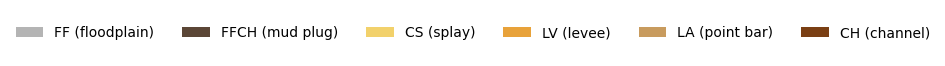

In [2]:
# Master plotting helper used by every section below.
# Layout: 2 rows of 4 XY slices spanning Z, then a row of 2 XZ + 2 YZ
# cross-sections at quartile positions. Legend embedded in every figure.
_alluvsim_cmap, _alluvsim_norm = alluvsim_cmap()

def _legend_handles():
    return ([plt.Rectangle((0, 0), 1, 1, fc=FACIES_COLORS[c]) for c in sorted(FACIES_NAMES.keys())],
            [FACIES_NAMES[c] for c in sorted(FACIES_NAMES.keys())])


def plot_reservoir(layer, title, dpi=80):
    facies = (layer.facies_alluvsim if hasattr(layer, 'facies_alluvsim')
              else (layer.facies if hasattr(layer, 'facies') else layer.active)).astype(np.int8)
    nx, ny, nz = facies.shape
    iz_indices = np.linspace(0, nz - 1, 8, dtype=int)
    # 2 cross-sections each, at the 1/3 and 2/3 marks
    iy_pair = (ny // 3, 2 * ny // 3)
    ix_pair = (nx // 3, 2 * nx // 3)

    # 3 rows × 4 cols layout. Top two rows = 4 XY slices each.
    # Bottom row = 2 XZ + 2 YZ. Square-ish XY panels.
    fig = plt.figure(figsize=(13, 8.5), dpi=dpi)
    gs = fig.add_gridspec(3, 4, height_ratios=[2.2, 2.2, 1.4],
                          hspace=0.35, wspace=0.20)
    plot_kw = dict(cmap=_alluvsim_cmap, norm=_alluvsim_norm,
                   interpolation='nearest', origin='lower')

    # Two rows of 4 XY slices
    for j in range(8):
        row, col = j // 4, j % 4
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(facies[:, :, iz_indices[j]].T, aspect='equal', **plot_kw)
        ax.set_title(f'XY  z={iz_indices[j]}', fontsize=9)
        if col != 0:
            ax.set_yticklabels([])
        if row != 1:
            ax.set_xticklabels([])

    # Bottom row: 2 XZ + 2 YZ
    ax_xz1 = fig.add_subplot(gs[2, 0])
    ax_xz1.imshow(facies[:, iy_pair[0], :].T, aspect='auto', **plot_kw)
    ax_xz1.set_title(f'XZ iy={iy_pair[0]}', fontsize=9)
    ax_xz1.set_xlabel('ix'); ax_xz1.set_ylabel('iz')
    ax_xz2 = fig.add_subplot(gs[2, 1])
    ax_xz2.imshow(facies[:, iy_pair[1], :].T, aspect='auto', **plot_kw)
    ax_xz2.set_title(f'XZ iy={iy_pair[1]}', fontsize=9)
    ax_xz2.set_xlabel('ix')
    ax_yz1 = fig.add_subplot(gs[2, 2])
    ax_yz1.imshow(facies[ix_pair[0], :, :].T, aspect='auto', **plot_kw)
    ax_yz1.set_title(f'YZ ix={ix_pair[0]}', fontsize=9)
    ax_yz1.set_xlabel('iy'); ax_yz1.set_ylabel('iz')
    ax_yz2 = fig.add_subplot(gs[2, 3])
    ax_yz2.imshow(facies[ix_pair[1], :, :].T, aspect='auto', **plot_kw)
    ax_yz2.set_title(f'YZ ix={ix_pair[1]}', fontsize=9)
    ax_yz2.set_xlabel('iy')

    # Legend on every figure (bottom of the figure)
    handles, labels = _legend_handles()
    fig.legend(handles, labels, loc='lower center', ncol=6,
               bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=False)
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.00)
    plt.show()

    n = facies.size
    parts = [f'NTG={layer.active.mean()*100:5.1f}%']
    for c in sorted(FACIES_NAMES.keys()):
        frac = (facies == c).sum() / n * 100
        if frac > 0.05:
            parts.append(f'{FACIES_NAMES[c].split()[0]}={frac:.1f}%')
    print('  '.join(parts))


def show_legend():
    fig, ax = plt.subplots(figsize=(8, 0.6))
    ax.axis('off')
    handles, labels = _legend_handles()
    ax.legend(handles, labels, loc='center', ncol=6, frameon=False, fontsize=10)
    plt.show()

show_legend()

In [3]:
# Common grid for all channel examples — matches the dataset pipeline
# that you'll use for the 10M-reservoir generation (64 × 64 × 32).
GRID = dict(nx=64, ny=64, nz=32, x_len=640, y_len=640, z_len=16, top_depth=0)
SEED = 69069

# Slightly bumped channel-width-to-depth ratio in every preset call —
# real channels at this grid resolution look better with W:D ~ 1.4× the
# canonical Alluvsim values, which puts the channel at 4-6 cells wide
# instead of 2-3 (which looked thin).
CHWDR_BUMP = 1.4

def build_channel(preset, layer_cls=gr.MeanderingChannelLayer, seed=SEED, **overrides):
    """Helper: build a channel layer using a preset dict + optional overrides.

    Auto-rescales preset's ``level_z`` and ``mCHsource`` to match the
    current GRID — presets are calibrated for the original Alluvsim
    80×50×20 grid; without rescaling on a 64×64×32 grid the channel
    only fills ~60% of Z and lands off-centre in Y. Also bumps
    ``mCHwdratio`` by ``CHWDR_BUMP`` for slightly chunkier channels.
    """
    layer = layer_cls(**GRID)
    np.random.seed(seed)
    kw = dict(preset)
    if 'level_z' in kw and 'level_z' not in overrides:
        z_max = max(kw['level_z'])
        scale = GRID['z_len'] * 0.95 / z_max if z_max > 0 else 1.0
        kw['level_z'] = [z * scale for z in kw['level_z']]
    if 'mCHsource' not in overrides:
        kw['mCHsource'] = GRID['y_len'] / 2
    if 'mCHwdratio' in kw and 'mCHwdratio' not in overrides:
        kw['mCHwdratio'] = kw['mCHwdratio'] * CHWDR_BUMP
    kw.update(overrides)
    kw.setdefault('output_facies', 'alluvsim')
    kw.setdefault('seed', seed)
    layer.create_geology(**kw)
    return layer

---
## Showcase: meandering channel evolution per Pyrcz 2003 Fig 4

Two snapshots of a single meandering river evolving by Sun-1996 bank-retreat
migration, with no avulsion and no streamline reseeds. Each fresh migration
step grows the existing bends (cutbank erodes the OUTER bank, point-bar /
lateral-accretion cells deposit on the INNER bank, and levees flank the
outer cutbank). Eventually neck-cutoffs sever loops and reset local
sinuosity, reproducing the textbook architecture from Pyrcz 2003 *Bank
Retreat Meandering Fluvial Process-based Model* (CCG report 5, Figure 4).

* **Case A — Pyrcz Fig 4 step ~3-4**: a single curvy channel covering about
  half the floodplain. LA scroll bars trace the migration history.
* **Case B — Pyrcz Fig 4 step ~11-12**: highly sinuous channel with multiple
  tight loops, neck-cutoff oxbows, and LA cells covering nearly the whole
  floodplain.

The porosity field at the channel-belt Z slice traces the lateral-accretion
ribbons left behind as the channel migrated.

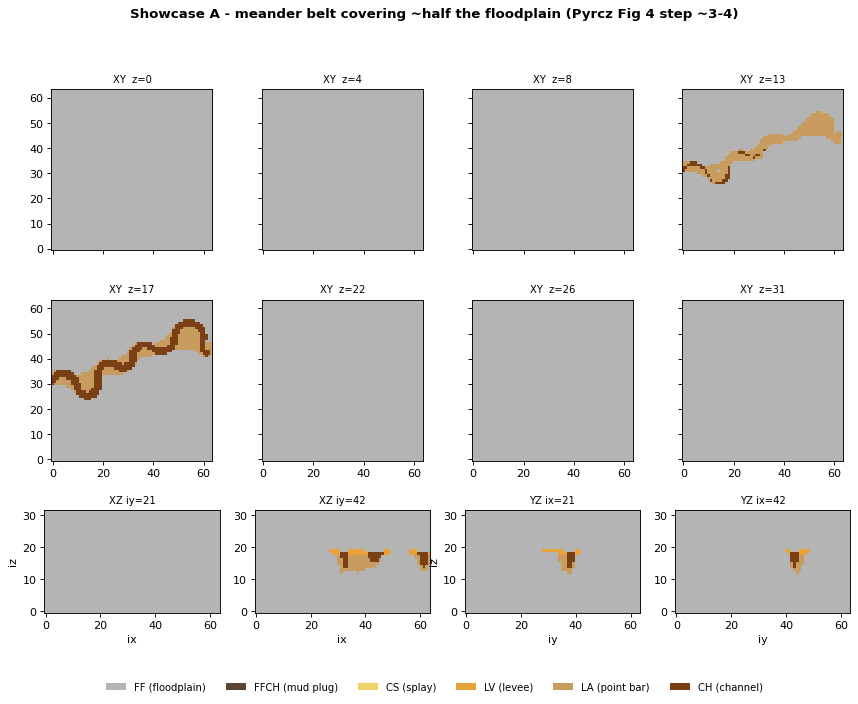

NTG=  2.7%  FF=97.3%  LV=0.6%  LA=1.2%  CH=0.9%


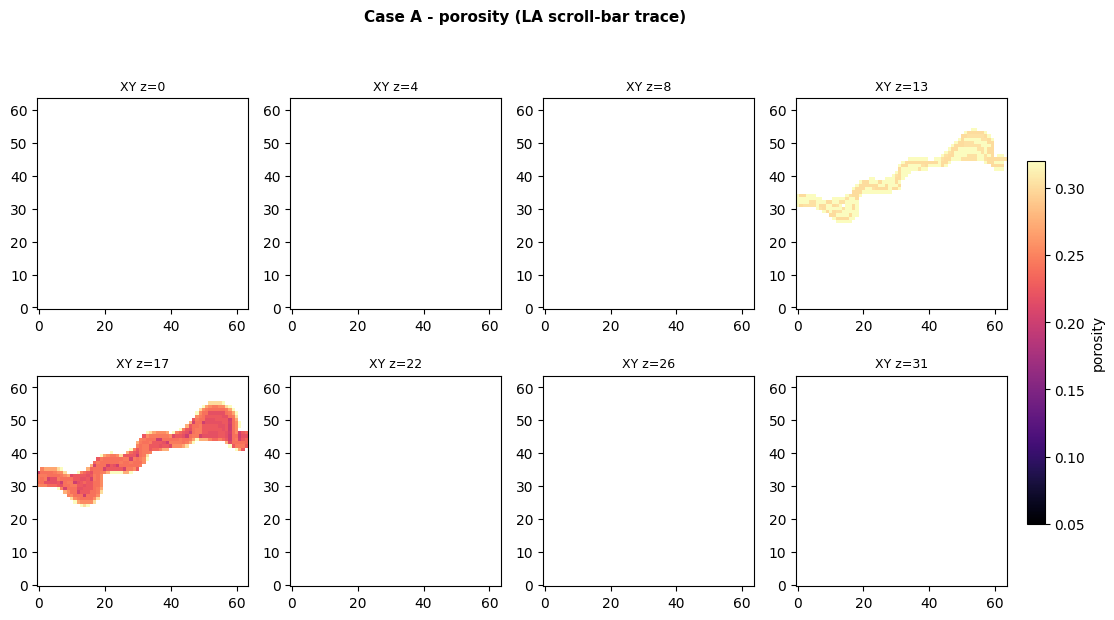

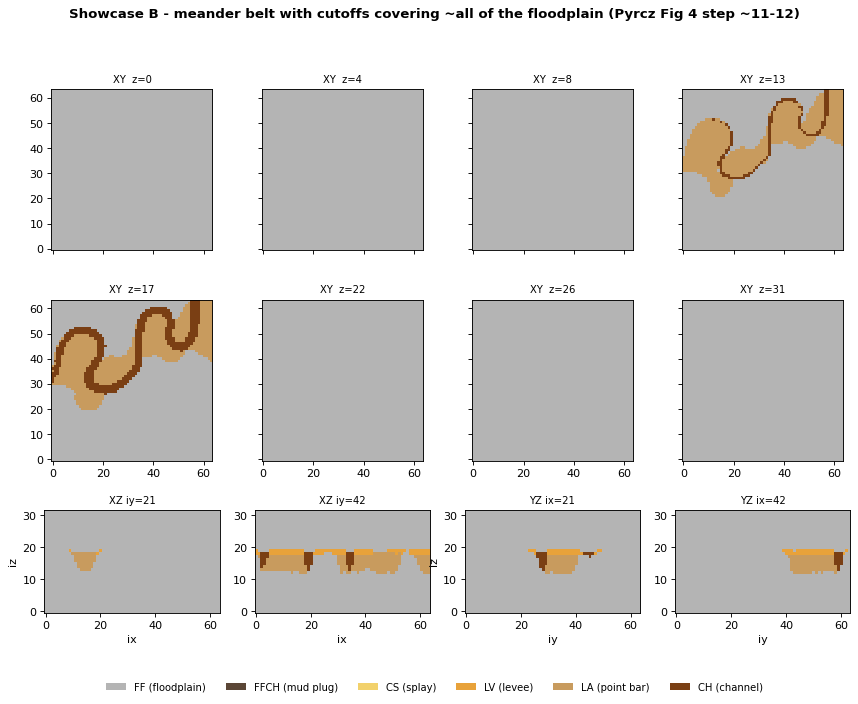

NTG=  7.1%  FF=92.9%  LV=1.4%  LA=4.1%  CH=1.5%


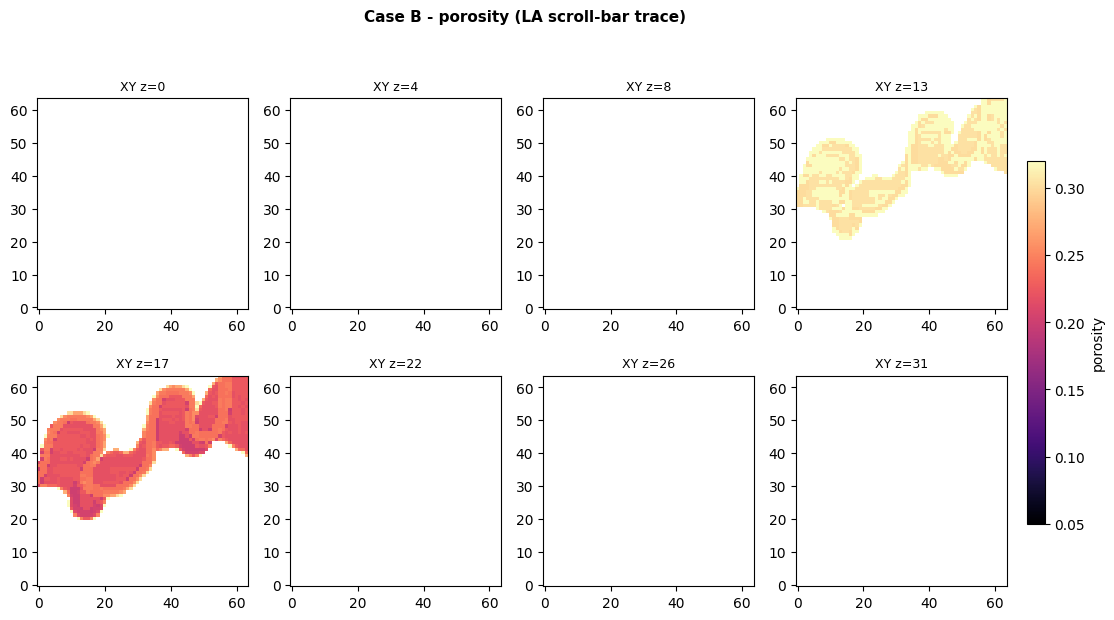

In [4]:
# Pyrcz 2003 Table 1 hydraulic parameters (Cf=0.0036, A=10, Q=3.256) plus
# a single deterministic streamline (stdevCHsource=1) so we run one channel
# from start to finish without any pool reseeds.
PYRCZ_BASE = dict(
    nlevel=1,
    NTGtarget=0.99,
    probAvulOutside=0.0, probAvulInside=0.0,
    mCHsinu=1.5, stdevCHsinu=0.03,
    stdevCHwdratio=0.5,
    mCHdepth=3.0, stdevCHdepth=0.2,
    mLVdepth=0.8, stdevLVdepth=0.1,
    mLVwidth=40.0, stdevLVwidth=5.0,
    mLVheight=0.5, stdevLVheight=0.05,
    mLVasym=0.0, mLVthin=0.0,
    mFFCHprop=0.0, stdevFFCHprop=0.0,
    mCSnum=0.0, mCSnumlobe=0.0, stdevCSnum=0.0, stdevCSnumlobe=0.0,
    mdistMigrate=2.0, stdevdistMigrate=0.4,
    Cf=0.0036, scour_factor=10.0, gradient=0.001, Q=3.256,
    stdevCHsource=1.0,
)

# Pass mCHwdratio and level_z as build_channel overrides so the helper's
# CHWDR_BUMP and z-rescaling stay out of the way; we want the Pyrcz Fig 4
# parameters to come through verbatim.
_PYRCZ_OVERRIDES = dict(
    mCHwdratio=11.0,
    level_z=[GRID['z_len'] * 0.6],
    mCHsource=GRID['y_len'] / 2,
)


def _show_porosity(layer, title):
    """Companion porosity plot - high values trace the migration history."""
    poro = layer.poro_mat
    nx, ny, nz = poro.shape
    iz_indices = np.linspace(0, nz - 1, 8, dtype=int)
    fig, axes = plt.subplots(2, 4, figsize=(13, 6.6))
    for j, iz in enumerate(iz_indices):
        ax = axes[j // 4, j % 4]
        sl = poro[:, :, iz]
        masked = np.where(sl > 0.06, sl, np.nan)
        im = ax.imshow(masked.T, cmap='magma', vmin=0.05, vmax=0.32,
                       origin='lower', interpolation='nearest', aspect='equal')
        ax.set_title(f'XY z={iz}', fontsize=9)
    fig.suptitle(f'{title} - porosity (LA scroll-bar trace)',
                 fontsize=11, fontweight='bold', y=1.00)
    fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02, label='porosity')
    plt.show()


# Case A - half-floodplain belt (Pyrcz Fig 4 step ~3-4)
layer_A = build_channel({**PYRCZ_BASE, 'ntime': 50}, seed=42, **_PYRCZ_OVERRIDES)
plot_reservoir(layer_A, 'Showcase A - meander belt covering ~half the floodplain (Pyrcz Fig 4 step ~3-4)')
_show_porosity(layer_A, 'Case A')

# Case B - full-floodplain belt (Pyrcz Fig 4 step ~11-12)
layer_B = build_channel({**PYRCZ_BASE, 'ntime': 200}, seed=42, **_PYRCZ_OVERRIDES)
plot_reservoir(layer_B, 'Showcase B - meander belt with cutoffs covering ~all of the floodplain (Pyrcz Fig 4 step ~11-12)')
_show_porosity(layer_B, 'Case B')

---
## 1. PV Shoestring

**Paleo-valley shoestring channel.** Low-NTG (`NTGtarget=0.10`), low avulsion (`probAvulIn=0.05`), high sinuosity (`mCHsinu=1.6`), narrow channels (`mCHwdratio=10`). Result: a single sinuous channel per Z slice with prominent **lateral-accretion (LA) wedges** on the inside of bends. Levees (LV) frame the channel; no FFCH (no mud plugs).

Geological analogue: Cretaceous Cardium Fm., Western Canada Basin.

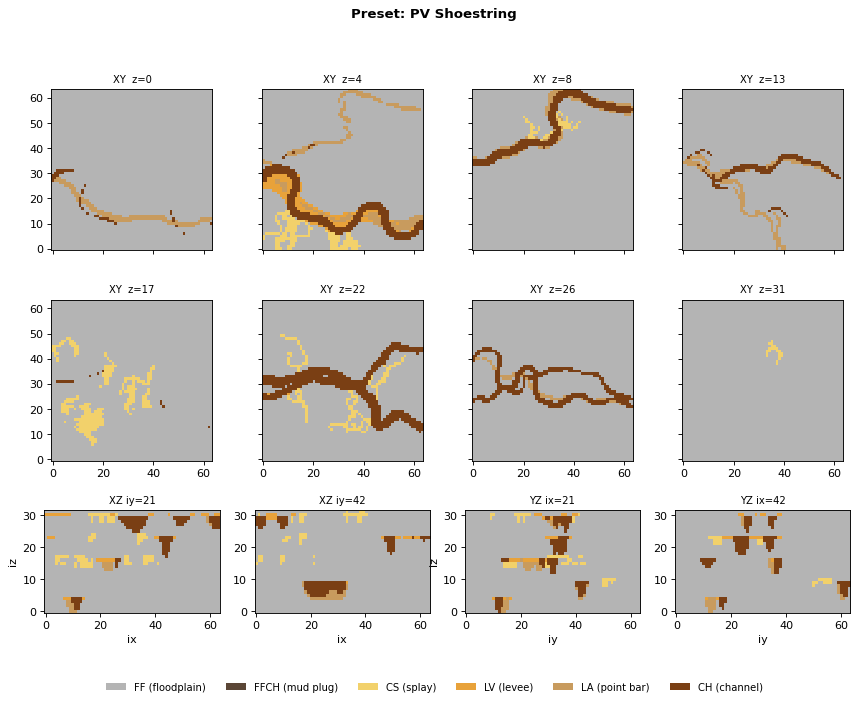

NTG= 10.6%  FF=89.4%  CS=2.1%  LV=1.2%  LA=1.8%  CH=5.5%


In [5]:
layer = build_channel(PV_SHOESTRING)
plot_reservoir(layer, 'Preset: PV Shoestring')

---
## 2. CB Jigsaw

**Channel-and-bar jigsaw** (high in-model avulsion). High `probAvulInside=0.40` makes the streamline branch frequently mid-grid; high `mFFCHprop=0.5` plugs each abandoned channel half-way with mud. Result: amalgamated **multi-thread CH bodies + dark FFCH baffles** weaving between them — the classic CB-jigsaw look.

Geological analogue: Pennsylvanian Atoka Fm. / Brent Group reservoirs.

Note: uses `BraidedChannelLayer` (which is just `MeanderingChannelLayer` with CB-jigsaw defaults — same engine).

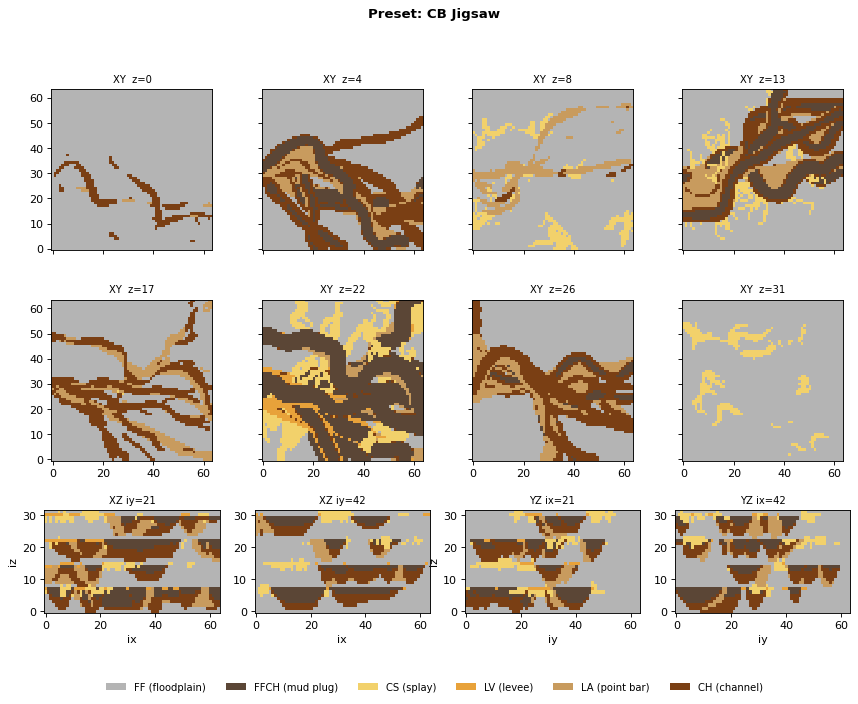

NTG= 30.5%  FF=58.7%  FFCH=10.8%  CS=6.8%  LV=1.3%  LA=8.0%  CH=14.5%


In [6]:
layer = build_channel(CB_JIGSAW, layer_cls=gr.BraidedChannelLayer)
plot_reservoir(layer, 'Preset: CB Jigsaw')

---
## 3. CB Labyrinth

**Channel-and-bar labyrinth**. Same channel geometry as CB-jigsaw but **many aggradation levels** (`nlevel=6`) and **low avulsion** (`probAvulIn=0.05`). Each level gets one narrow channel ribbon; the result is **isolated CH lenses** at distinct Z elevations rather than amalgamated sheets.

Geological analogue: Tertiary Tyler Fm., Williston Basin.

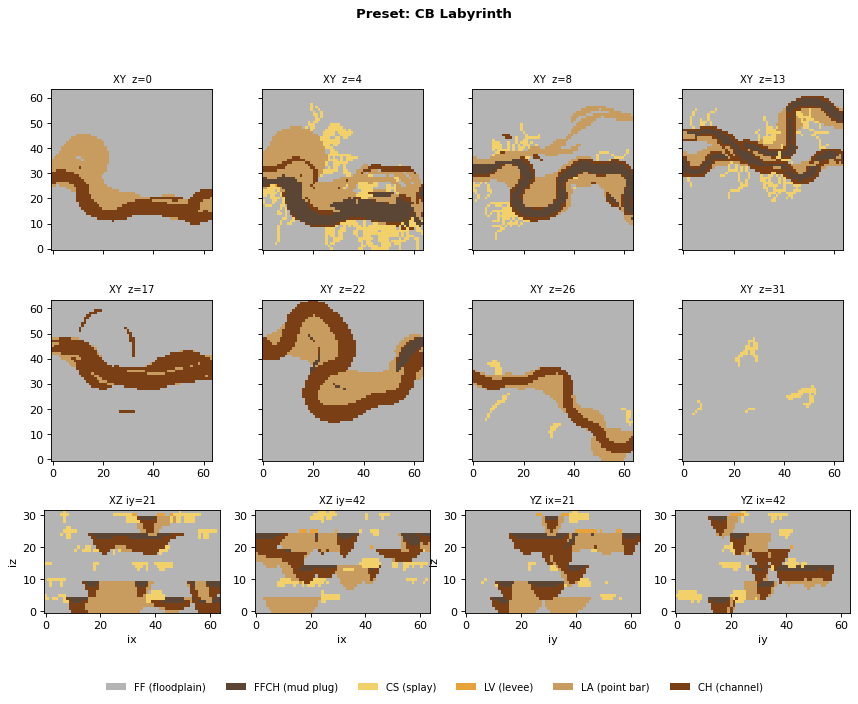

NTG= 25.8%  FF=70.5%  FFCH=3.6%  CS=4.9%  LV=0.4%  LA=10.4%  CH=10.2%


In [7]:
layer = build_channel(CB_LABYRINTH)
plot_reservoir(layer, 'Preset: CB Labyrinth')

---
## 4. SH Distal

**Sheet sand, distal facies association**. Very high NTG (`NTGtarget=0.50`), wide deep channels (`mCHwdratio=18`, `mCHdepth=5`), and very thick wide levees (`mLVwidth=150`, `mLVdepth=1.2`). Result: amalgamated **sand sheet** with overbank LV blanket dominating the floodplain. No mud plugs (`mFFCHprop=0`).

Geological analogue: distal portion of the Booch sandstone, Arkoma Basin.

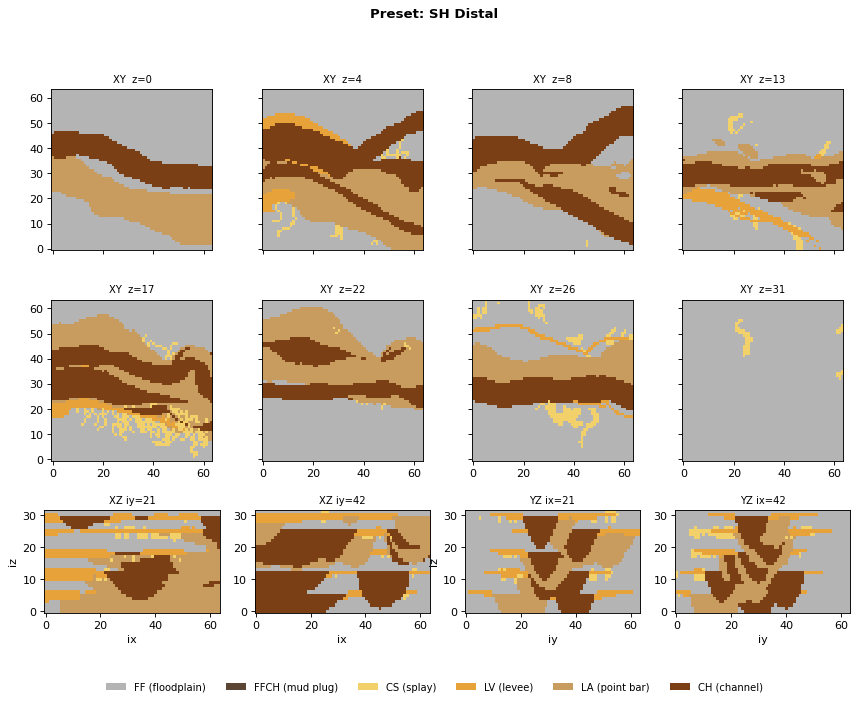

NTG= 50.3%  FF=49.7%  CS=1.8%  LV=8.4%  LA=19.5%  CH=20.6%


In [8]:
layer = build_channel(SH_DISTAL)
plot_reservoir(layer, 'Preset: SH Distal')

---
## 5. SH Proximal

**Sheet sand, proximal facies association**. High NTG (`NTGtarget=0.40`), heavy avulsion (`probAvulIn=0.35`), wide shallow channels (`mCHwdratio=22`, `mCHdepth=3.5`). Result: **fully amalgamated channel sand body** with FFCH mud plugs marking abandoned reaches.

Geological analogue: proximal Booch sandstone, Arkoma Basin.

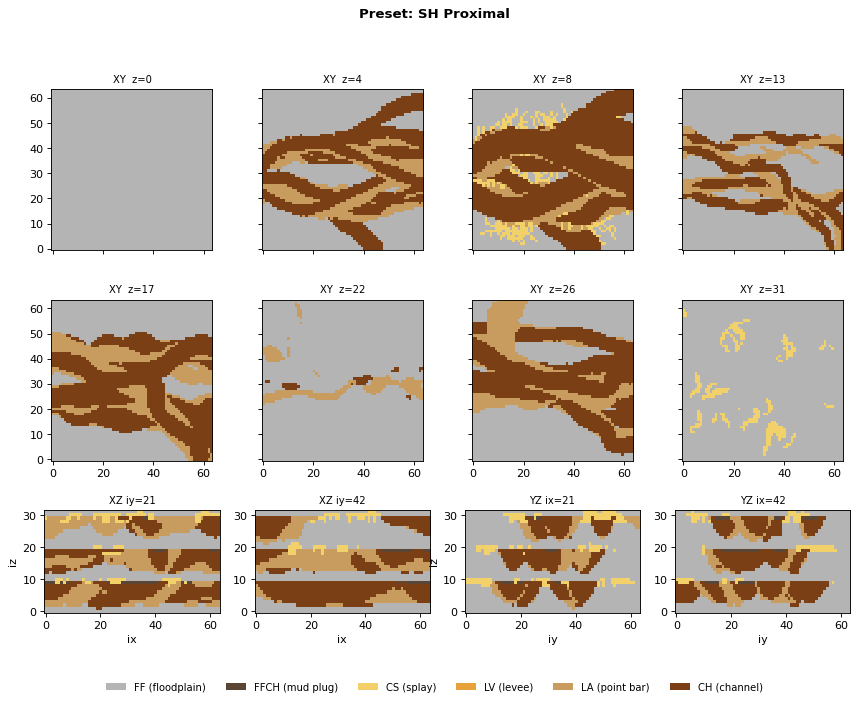

NTG= 40.0%  FF=58.7%  FFCH=1.3%  CS=5.3%  LA=11.3%  CH=23.4%


In [9]:
layer = build_channel(SH_PROXIMAL, layer_cls=gr.BraidedChannelLayer)
plot_reservoir(layer, 'Preset: SH Proximal')

---
## 6. Sinuosity sweep — `mCHsinu`

Same PV-shoestring base, varying mean channel sinuosity from straight (1.05) to highly sinuous (1.95). Watch the channel transition from near-linear to tightly meandering.

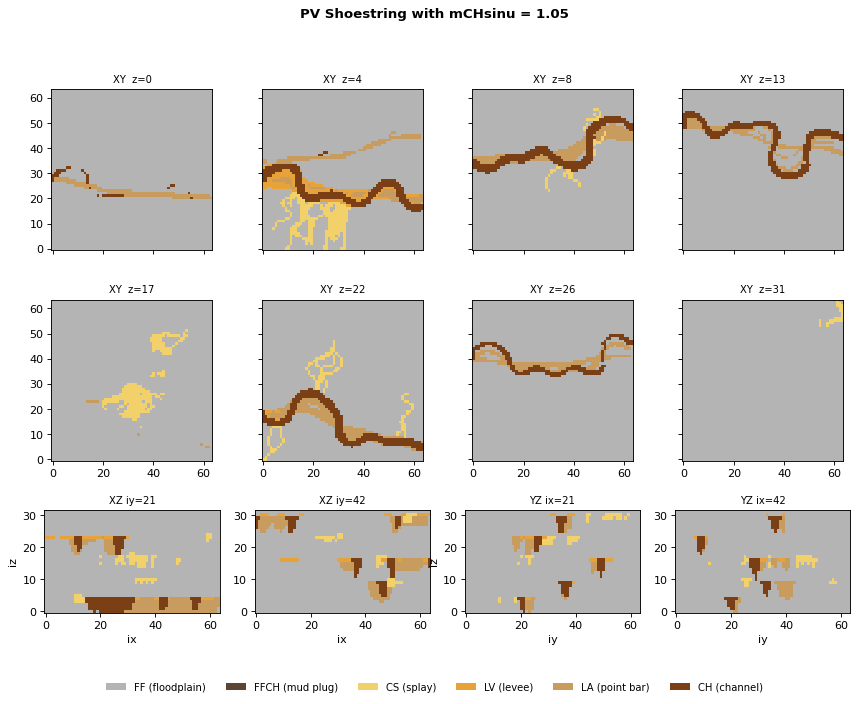

NTG= 10.5%  FF=89.5%  CS=2.2%  LV=1.0%  LA=3.1%  CH=4.2%


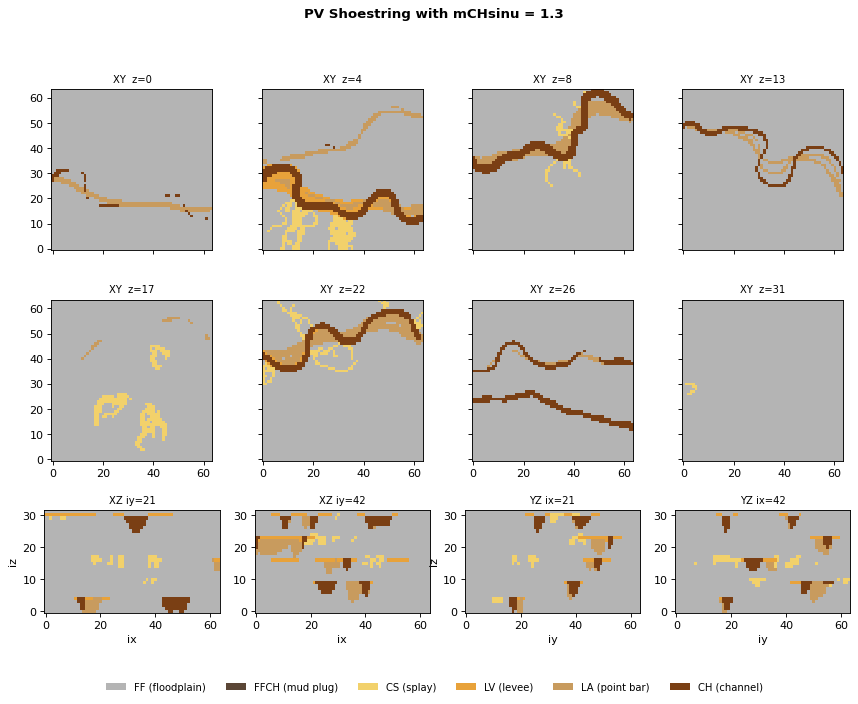

NTG= 10.5%  FF=89.5%  CS=2.0%  LV=1.4%  LA=2.9%  CH=4.2%


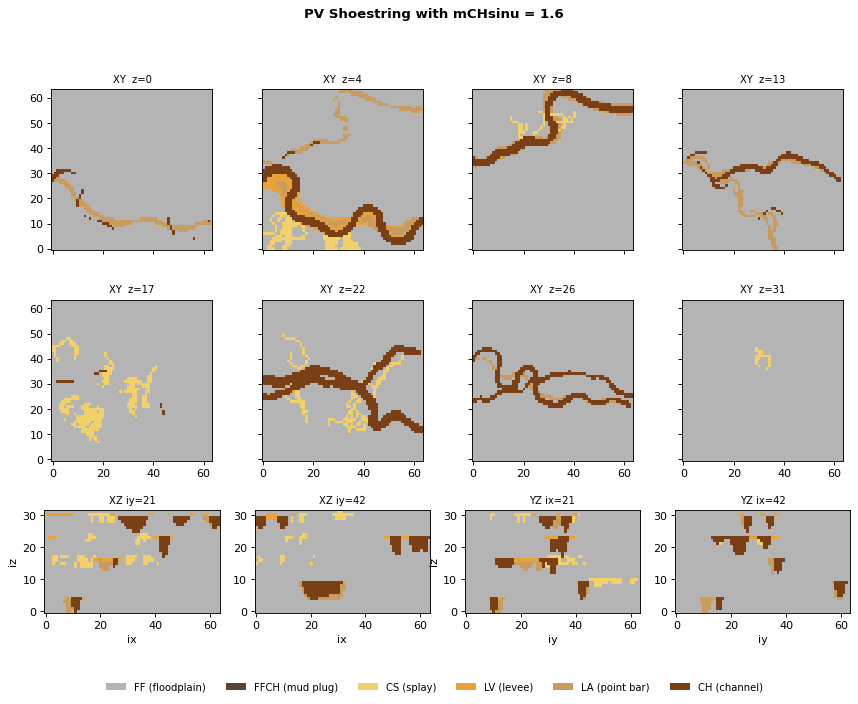

NTG= 10.6%  FF=89.4%  CS=2.1%  LV=1.2%  LA=1.8%  CH=5.5%


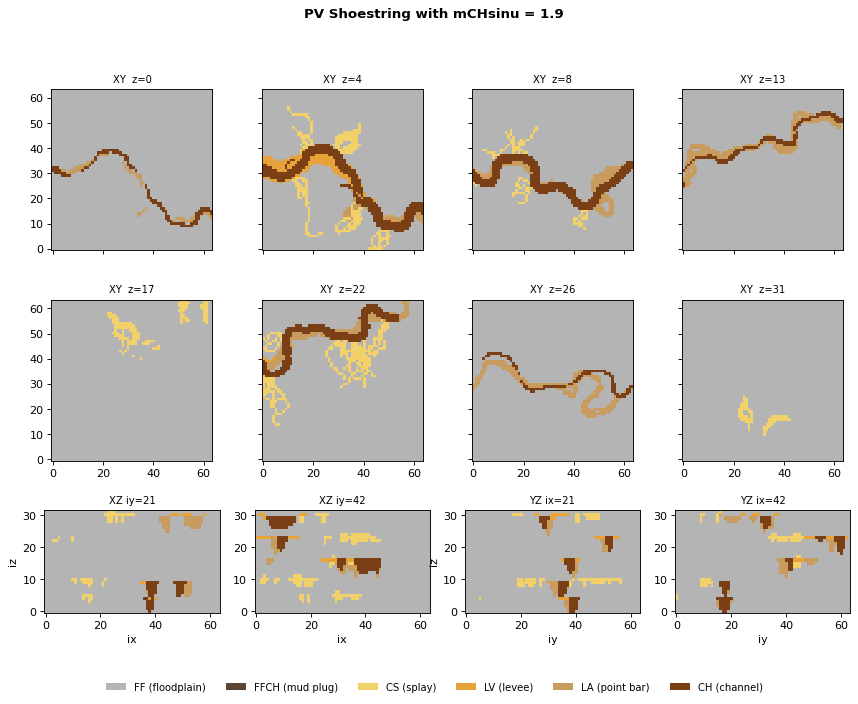

NTG= 10.6%  FF=89.4%  CS=2.7%  LV=1.1%  LA=2.8%  CH=4.0%


In [10]:
for sinu in [1.05, 1.30, 1.60, 1.90]:
    layer = build_channel(PV_SHOESTRING, mCHsinu=sinu, stdevCHsinu=0.05)
    plot_reservoir(layer, f'PV Shoestring with mCHsinu = {sinu}')

---
## 7. In-model avulsion sweep — `probAvulInside`

Same PV-shoestring channel geometry, varying the per-event probability of in-model avulsion. With more avulsion, each level gets multiple channel bodies at different Y positions instead of one continuous belt.

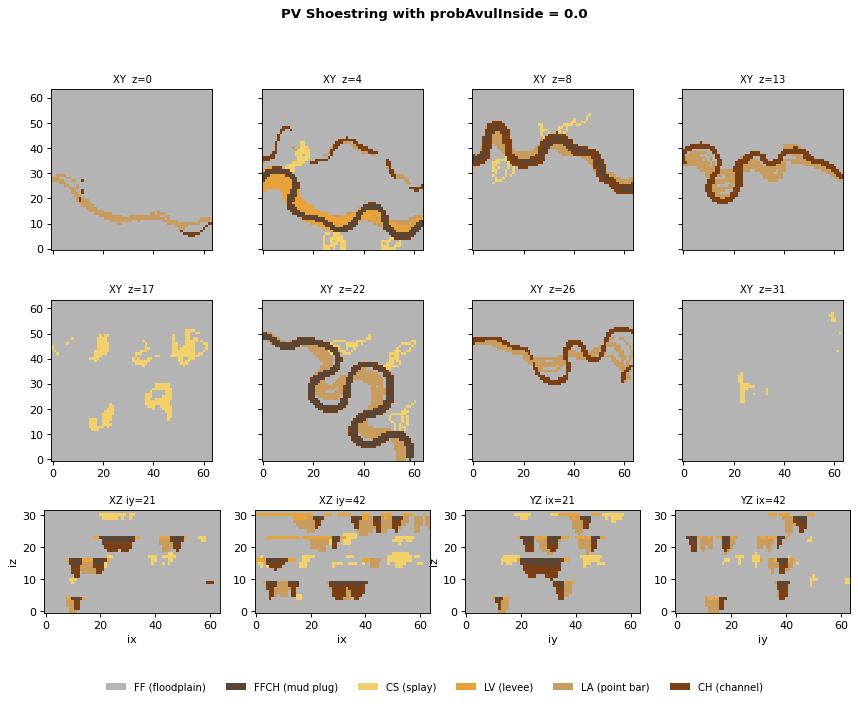

NTG= 10.7%  FF=87.3%  FFCH=2.0%  CS=2.0%  LV=1.5%  LA=3.8%  CH=3.4%


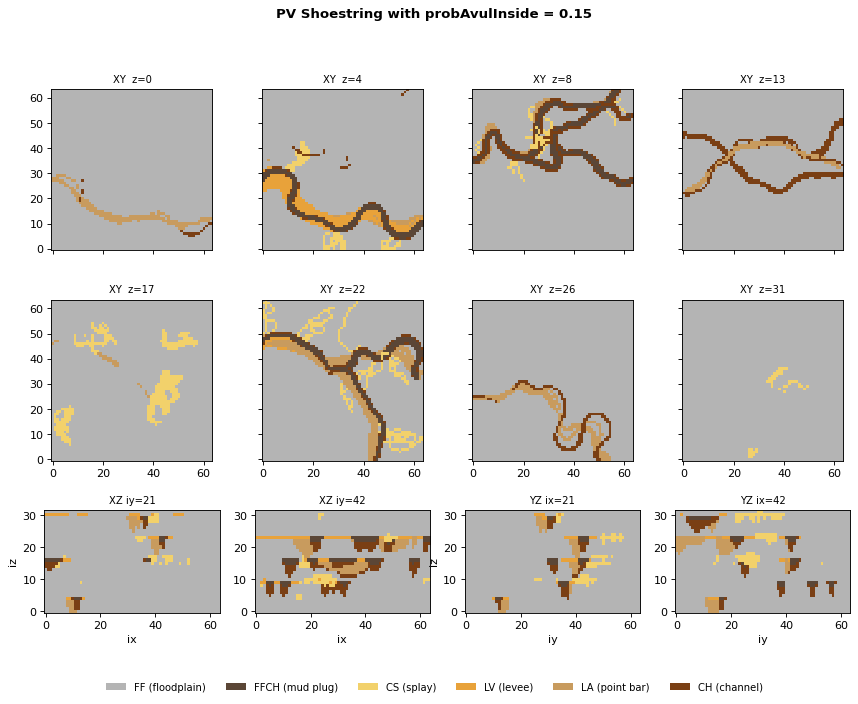

NTG= 10.7%  FF=87.4%  FFCH=1.9%  CS=2.7%  LV=1.4%  LA=2.9%  CH=3.6%


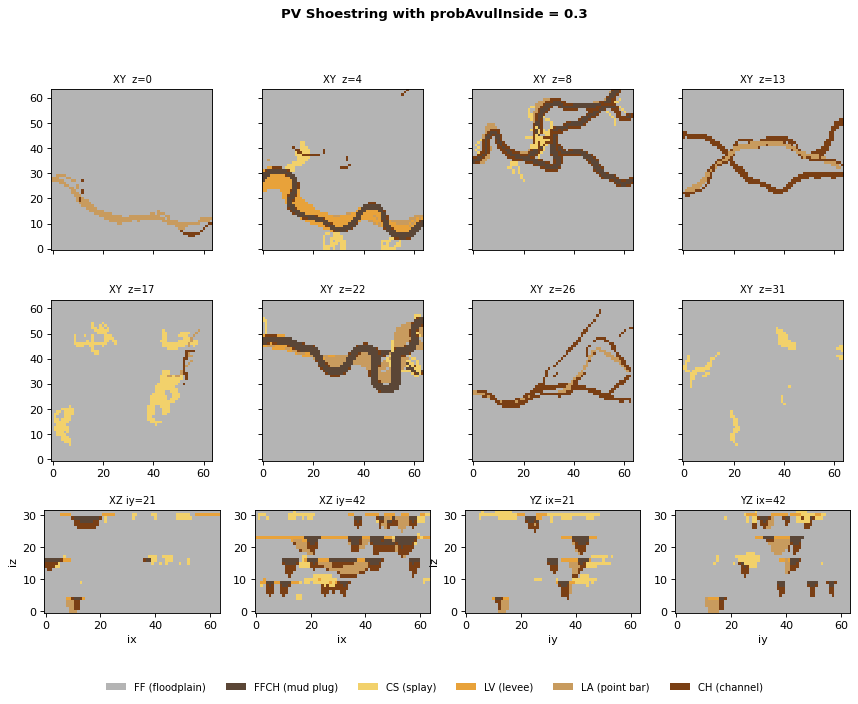

NTG= 10.3%  FF=87.2%  FFCH=2.6%  CS=2.6%  LV=1.5%  LA=2.2%  CH=4.0%


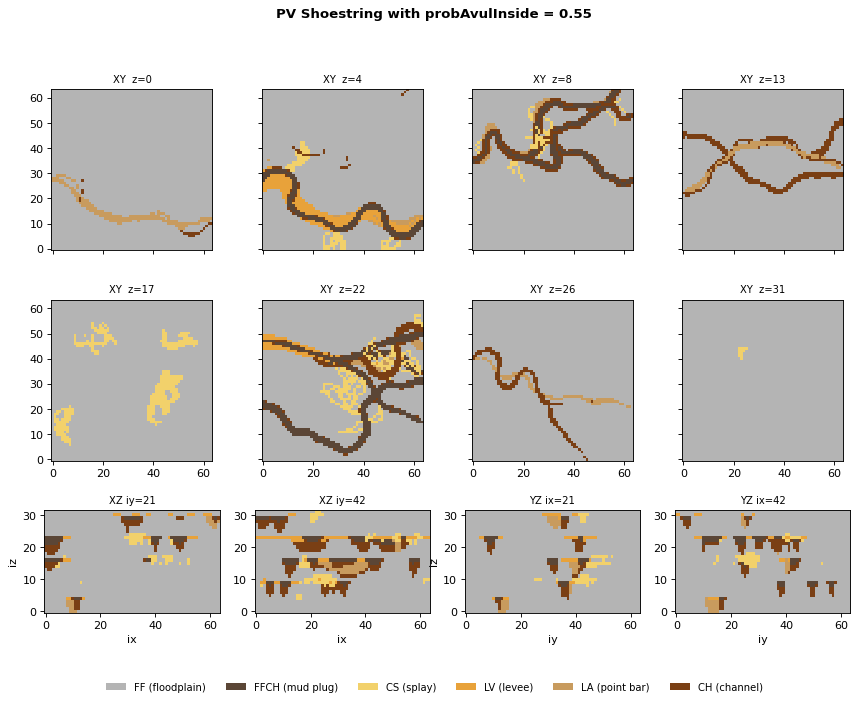

NTG= 10.2%  FF=87.4%  FFCH=2.5%  CS=2.5%  LV=1.7%  LA=1.6%  CH=4.3%


In [11]:
for p_in in [0.0, 0.15, 0.30, 0.55]:
    layer = build_channel(PV_SHOESTRING, probAvulInside=p_in, mFFCHprop=0.4, stdevFFCHprop=0.1)
    plot_reservoir(layer, f'PV Shoestring with probAvulInside = {p_in}')

---
## 8. Mud-plug fraction sweep — `mFFCHprop`

CB-jigsaw base, varying the fraction of each abandoned channel that becomes FFCH (dark-brown mud plug). At 0.0 every abandonment leaves residual sand; at 1.0 every abandonment becomes a full mud plug.

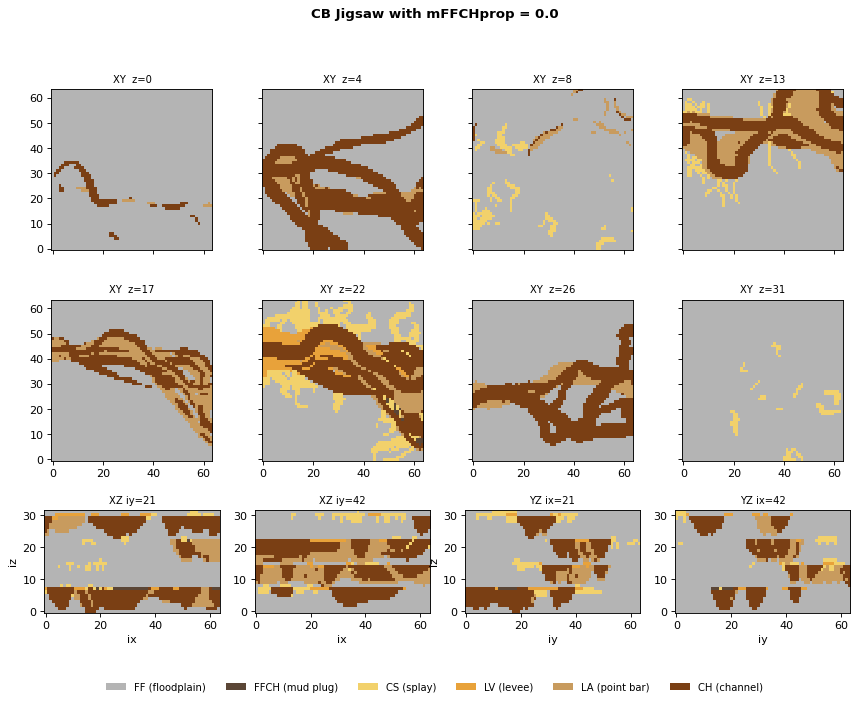

NTG= 30.1%  FF=69.7%  FFCH=0.2%  CS=4.3%  LV=1.2%  LA=6.2%  CH=18.3%


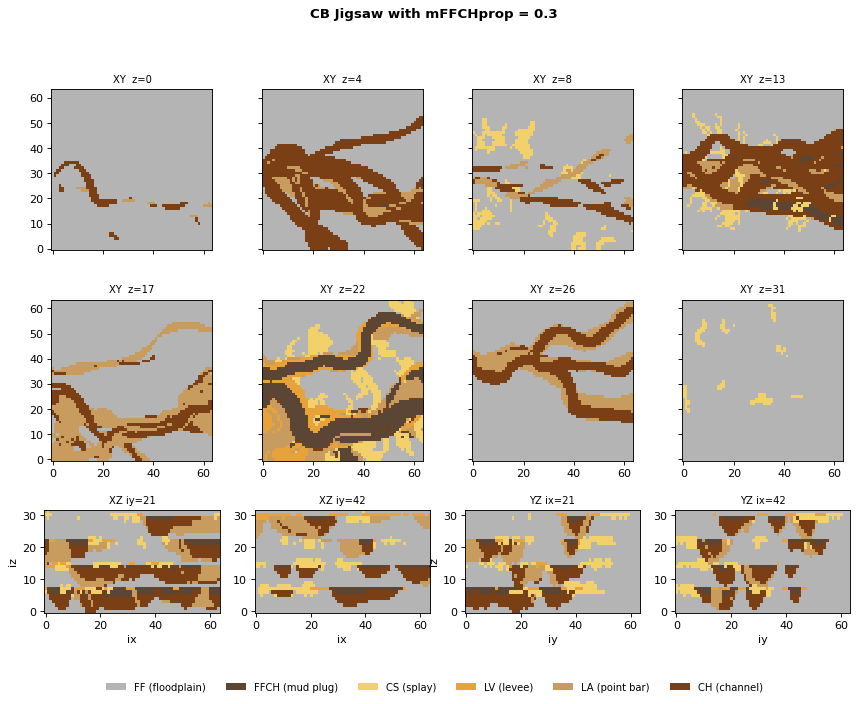

NTG= 29.9%  FF=65.4%  FFCH=4.7%  CS=5.4%  LV=1.4%  LA=8.6%  CH=14.6%


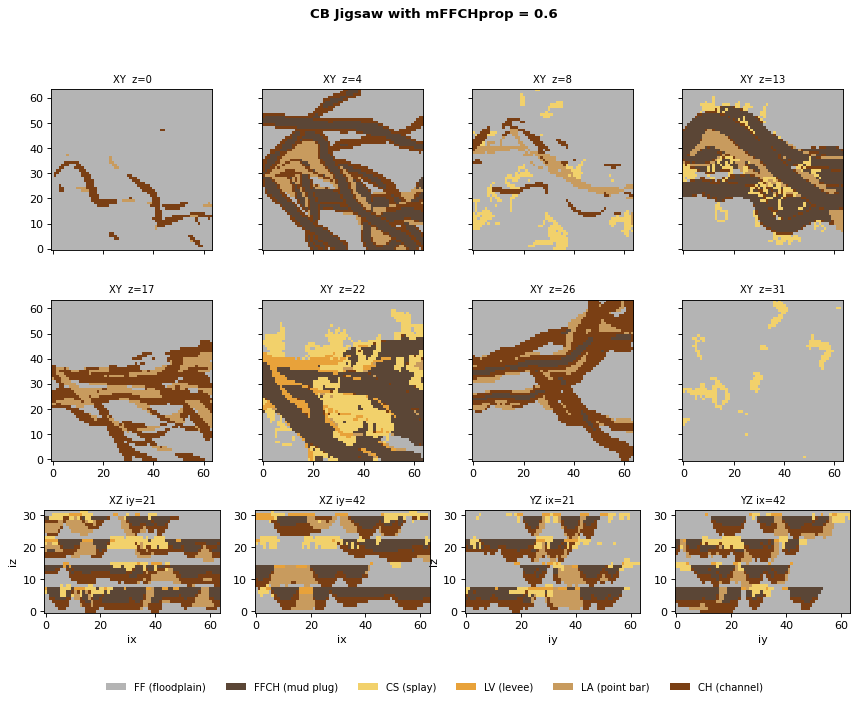

NTG= 29.9%  FF=55.0%  FFCH=15.1%  CS=7.1%  LV=1.5%  LA=6.4%  CH=14.9%


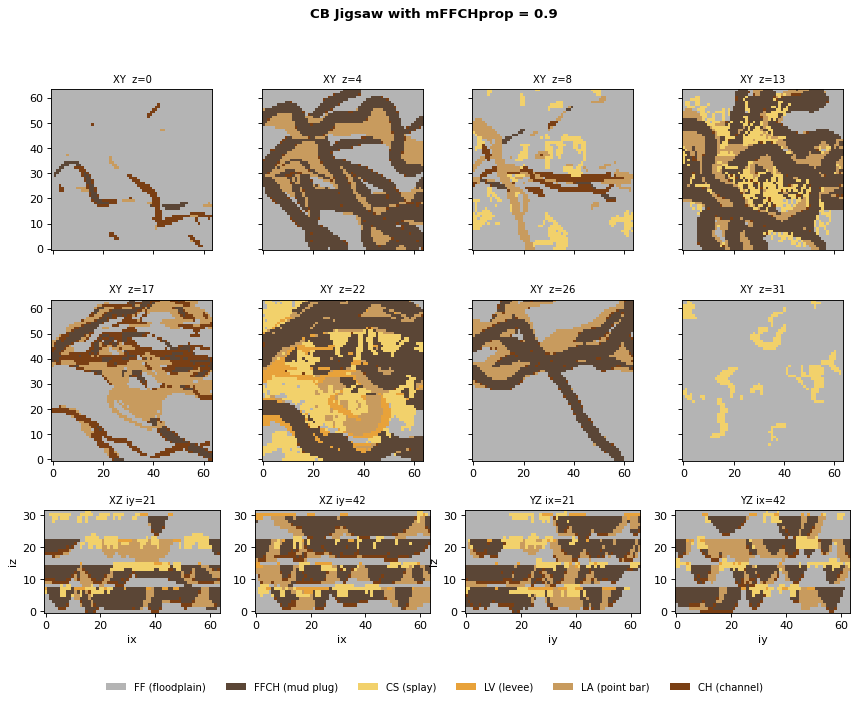

NTG= 29.0%  FF=44.6%  FFCH=26.4%  CS=8.9%  LV=2.0%  LA=13.1%  CH=5.0%


In [12]:
for prop in [0.0, 0.3, 0.6, 0.9]:
    layer = build_channel(CB_JIGSAW, layer_cls=gr.BraidedChannelLayer, mFFCHprop=prop, stdevFFCHprop=0.05)
    plot_reservoir(layer, f'CB Jigsaw with mFFCHprop = {prop}')

---
## 9. Crevasse splays (CS) enabled

All 5 presets disable crevasse splays by default (`mCSnum=0`). Here we force CS on with the canonical Alluvsim splay geometry — yellow lobate bodies extending perpendicular to the channel from high-curvature bends.

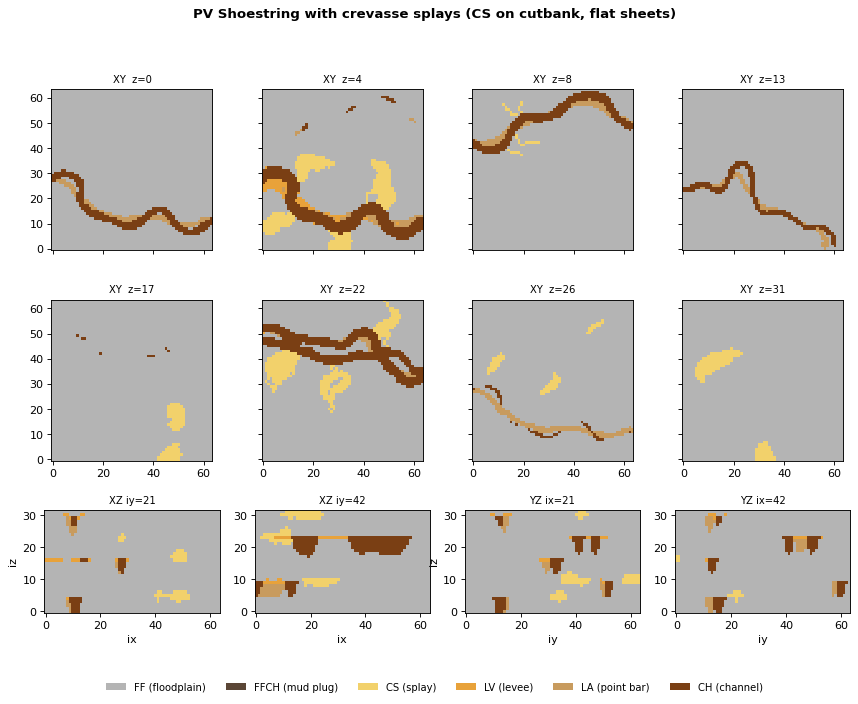

NTG= 10.8%  FF=89.2%  CS=3.4%  LV=0.8%  LA=1.5%  CH=5.1%


In [13]:
layer = build_channel(
    PV_SHOESTRING,
    mCSnum=2.0, stdevCSnum=0.5,
    mCSnumlobe=2.0, stdevCSnumlobe=0.5,
    mCSLOLL=250.0, mCSLOWW=80.0, mCSLOl=120.0, mCSLOw=15.0,
    # Alluvsim defaults: splays are FLAT lobate sheets.
    # Max thickness = (mCSLOWW/2) * (hwratio + dwratio) = 40 * 0.05 = 2m.
    # With zsiz = 0.5m that's ~4 z-cells thick — visible in XZ but not
    # standing upright. (Earlier I'd bumped these to 0.15/0.08 for
    # visibility, which produced 10m-thick blocks — geologically wrong:
    # crevasse splays are thin overbank sheets, not vertical pillars.)
    mCSLO_hwratio=0.03, mCSLO_dwratio=0.02,
)
plot_reservoir(layer, 'PV Shoestring with crevasse splays (CS on cutbank, flat sheets)')

---
## 10. Output mode comparison: `'binary'` vs `'alluvsim'`

Same parameters, two output modes. `'binary'` collapses all 6 facies into 0/1 (shale/sand) for the dataset pipeline; `'alluvsim'` preserves the full categorical breakdown for inspection. The per-cell **porosity and permeability** are the same in both modes — only the `facies` array changes.

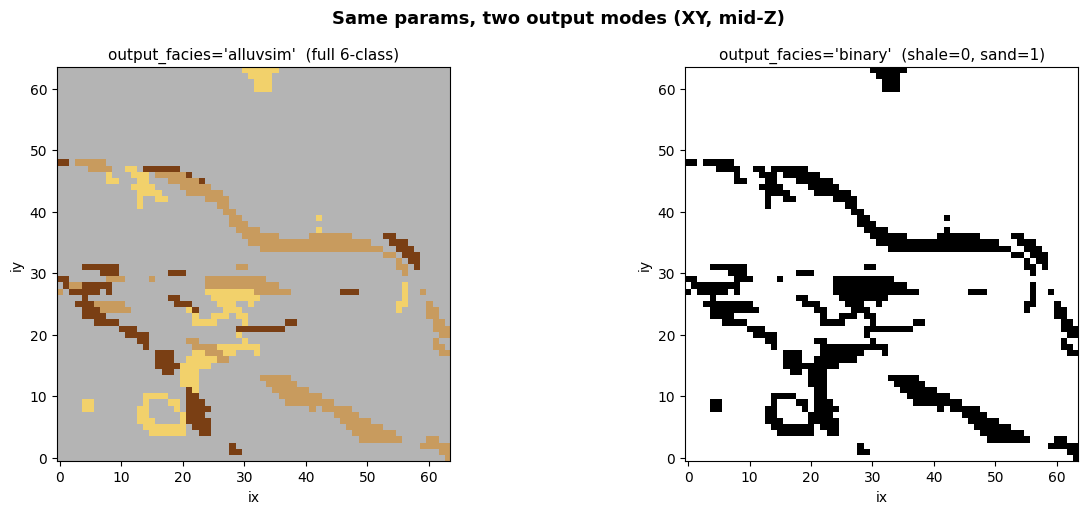

alluvsim: facies dtype=int8, unique=[-1, 0, 1, 2, 3, 4]
binary:   facies dtype=int8, unique=[0, 1]
Both have layer.facies_alluvsim populated (the un-collapsed 6-class array) for inspection.


In [14]:
layer_alluvsim = build_channel(CB_JIGSAW, layer_cls=gr.BraidedChannelLayer, output_facies='alluvsim')
layer_binary = build_channel(CB_JIGSAW, layer_cls=gr.BraidedChannelLayer, output_facies='binary')

# Side-by-side XY at mid-Z
iz = layer_alluvsim.facies.shape[2] // 2
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
cmap, norm = alluvsim_cmap()
axes[0].imshow(layer_alluvsim.facies_alluvsim[:, :, iz].T, cmap=cmap, norm=norm,
               origin='lower', interpolation='nearest')
axes[0].set_title("output_facies='alluvsim'  (full 6-class)", fontsize=11)
axes[1].imshow(layer_binary.facies[:, :, iz].T, cmap='Greys', vmin=0, vmax=1,
               origin='lower', interpolation='nearest')
axes[1].set_title("output_facies='binary'  (shale=0, sand=1)", fontsize=11)
for ax in axes:
    ax.set_xlabel('ix'); ax.set_ylabel('iy')
fig.suptitle('Same params, two output modes (XY, mid-Z)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"alluvsim: facies dtype={layer_alluvsim.facies.dtype}, unique={sorted(np.unique(layer_alluvsim.facies).tolist())}")
print(f"binary:   facies dtype={layer_binary.facies.dtype}, unique={sorted(np.unique(layer_binary.facies).tolist())}")
print(f"Both have layer.facies_alluvsim populated (the un-collapsed 6-class array) for inspection.")

---
## 11. Stochastic variability — same preset, different seeds

Stochastic models — different random seeds give different realisations of the same geological process. Useful for uncertainty studies.

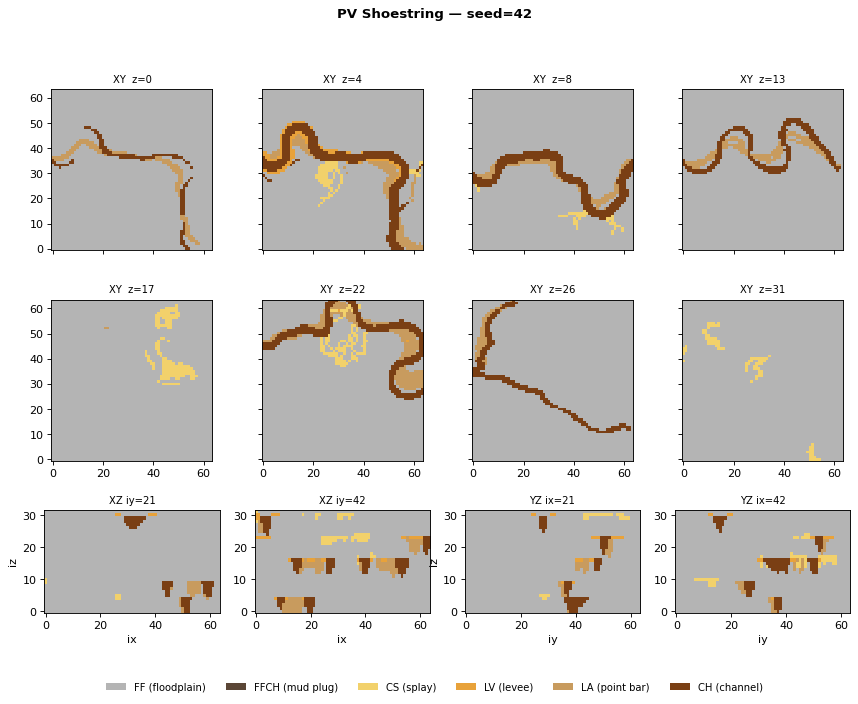

NTG= 10.6%  FF=89.4%  CS=1.6%  LV=1.1%  LA=2.6%  CH=5.3%


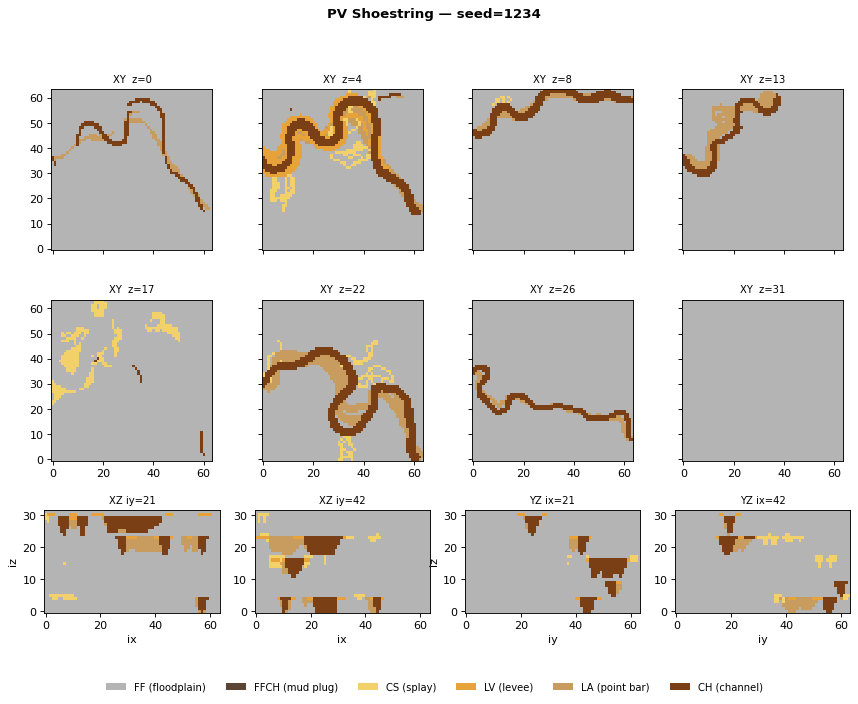

NTG= 10.6%  FF=89.4%  CS=1.4%  LV=1.1%  LA=2.7%  CH=5.3%


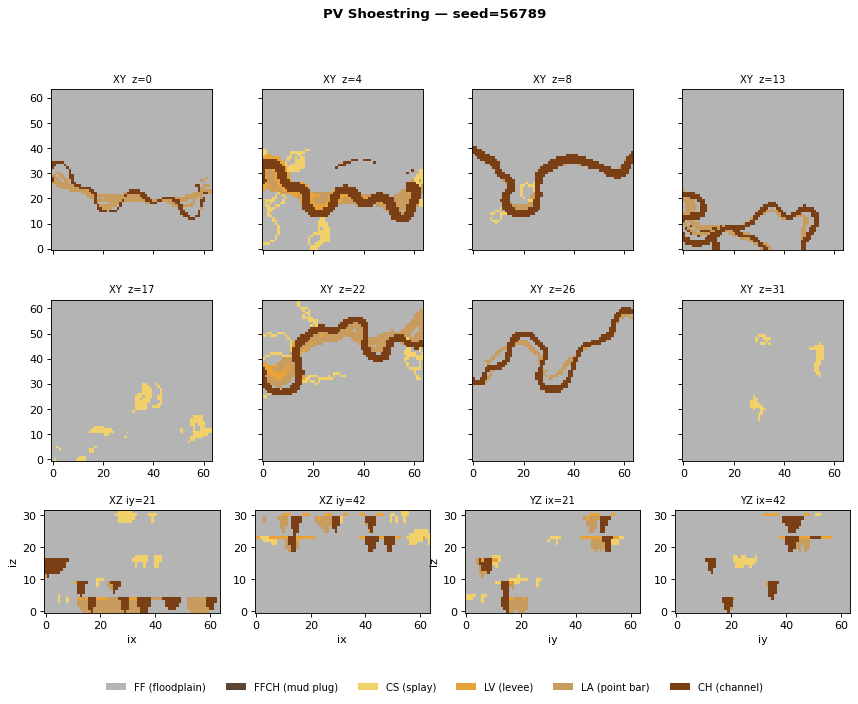

NTG= 10.9%  FF=89.1%  CS=1.7%  LV=1.2%  LA=2.5%  CH=5.4%


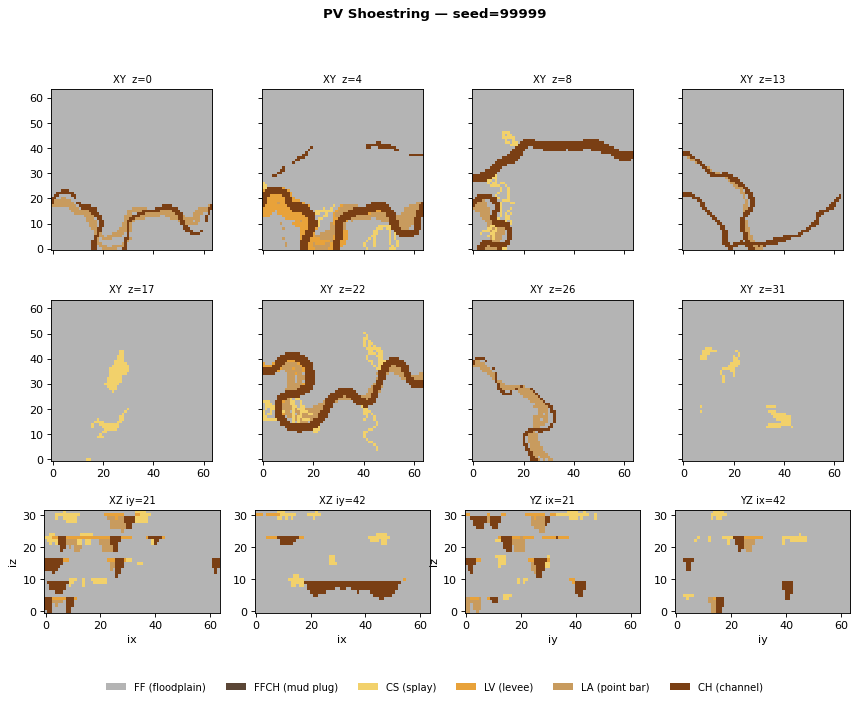

NTG= 10.4%  FF=89.6%  CS=1.7%  LV=1.3%  LA=2.4%  CH=5.0%


In [15]:
for seed in [42, 1234, 56789, 99999]:
    layer = build_channel(PV_SHOESTRING, seed=seed)
    plot_reservoir(layer, f'PV Shoestring — seed={seed}')

---
## 12. Other GeoRules layers (not Alluvsim, but supported)

GeoRules also has `DeltaLayer`, `LobeLayer`, `GaussianLayer` — these aren't Alluvsim ports but are part of the library. Quick rendering for completeness; these layers were intentionally left untouched during the Alluvsim parity work.

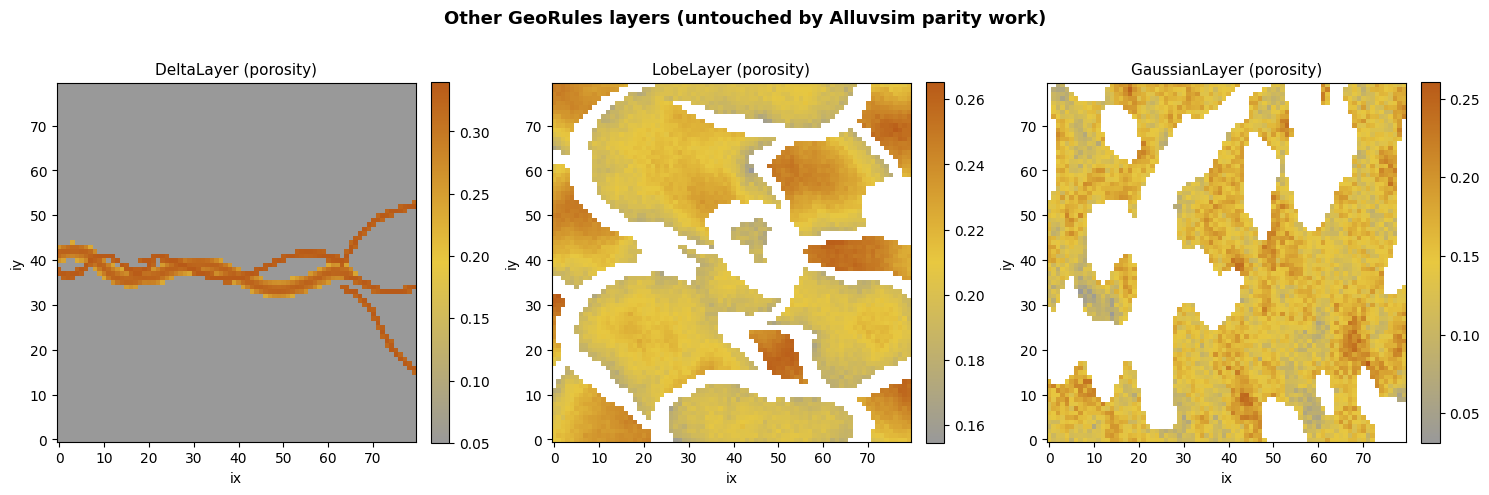

Delta:    NTG=6.4%
Lobe:     NTG=70.0%
Gaussian: NTG=60.0%


In [16]:
# Delta — distributary fan
delta = gr.DeltaLayer(nx=80, ny=80, nz=20, x_len=800, y_len=800, z_len=10, top_depth=0)
delta.create_geology(
    feeder_width=80.0, n_generations=6, fan_angle_deg=120.0,
    bifurcation_depth=4, fan_asymmetry=0.0, azimuth=0.0, dwratio=0.25,
)

# Lobe — turbidite lobes
lobe = gr.LobeLayer(nx=80, ny=80, nz=20, x_len=2000, y_len=2000, z_len=80, top_depth=5000)
lobe.create_geology(
    poro_ave=0.20, perm_ave=1.5, poro_std=0.03, perm_std=0.5, ntg=0.7,
    dhmin=4.0, dhmax=4.0, rmin=15, rmax=25,
    asp=1.5, m=100,
)

# Gaussian — SGS heterogeneity
gauss = gr.GaussianLayer(nx=80, ny=80, nz=20, x_len=2000, y_len=2000, z_len=80, top_depth=5000)
gauss.create_geology(
    poro_ave=0.15, perm_ave=1.2, poro_std=0.03, perm_std=0.4, ntg=0.6,
    facies_filter=(2.5, 5.0, 2.5), sand_filter=(1.5, 2.5, 1.5),
)

# Side-by-side XY at mid-Z
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, layer, name in zip(axes,
                            [delta, lobe, gauss],
                            ['DeltaLayer (porosity)', 'LobeLayer (porosity)', 'GaussianLayer (porosity)']):
    iz = layer.poro_mat.shape[2] // 2
    sl = layer.poro_mat[:, :, iz]
    masked = np.where(sl > 0, sl, np.nan)
    im = ax.imshow(masked.T, cmap='georules', origin='lower', interpolation='nearest')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('ix'); ax.set_ylabel('iy')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Other GeoRules layers (untouched by Alluvsim parity work)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Delta:    NTG={delta.active.mean()*100:.1f}%')
print(f'Lobe:     NTG={lobe.active.mean()*100:.1f}%')
print(f'Gaussian: NTG={gauss.active.mean()*100:.1f}%')

---
## Summary

All 6 Alluvsim facies (FF, FFCH, CS, LV, LA, CH) are generated by GeoRules' channel engine. The 5 Pyrcz canonical reservoir presets reproduce the architectures published in his 2004 thesis. Per-event Gaussian draws for ~50 parameters control everything from channel geometry to overbank elements.

For the 10M-reservoir dataset pipeline, use `output_facies='binary'` (default). For inspection / single-reservoir analysis, use `output_facies='alluvsim'`.

Per-facies porosity / permeability defaults live in `georules.layers.channel.FACIES_PROPS` — override per-call via the `facies_props={code: {...}}` kwarg on `create_geology`.